In [24]:
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms, utils
from torch.utils.data import DataLoader
%cd "C:/Users/mateo/Desktop/polymath-jr-drifting"
# The reusable nested-prefix implementation lives in src.matryoshka.
import importlib
import src.matryoshka as matryoshka_utils
matryoshka_utils = importlib.reload(matryoshka_utils)
from src.driftXpress import *
from src.eval import *
from src.training import (
    compose_objective,
    format_epoch_losses,
    gradient_report,
    per_loss_gradient_norms,
    set_requires_grad,
)
from src.matryoshka import (
    VAE,
    LatentGenerator,
    f,
    build_conditional_drift_cache,
    conditional_drift_loss,
    evaluate_matryoshka_model,
    training_loop as matryoshka_training_loop,
)
torch.manual_seed(7)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)


C:\Users\mateo\Desktop\polymath-jr-drifting
Using: cuda


In [2]:
transform = transforms.ToTensor()

SELECTED_DIGITS = (0, 8, 2, 4, 7, 9)
DIGIT_TO_CLASS = {digit: index for index, digit in enumerate(SELECTED_DIGITS)}
CLASS_TO_DIGIT = np.asarray(SELECTED_DIGITS)

train_data = datasets.MNIST("data", train=True, download=True, transform=transform)
test_data = datasets.MNIST("data", train=False, download=True, transform=transform)

def keep_selected_digits(dataset):
    selected = torch.tensor(SELECTED_DIGITS, dtype=dataset.targets.dtype)
    mask = torch.isin(dataset.targets, selected)
    dataset.data = dataset.data[mask]
    raw_targets = dataset.targets[mask]
    dataset.targets = torch.tensor(
        [DIGIT_TO_CLASS[int(digit)] for digit in raw_targets],
        dtype=torch.long,
    )
    return dataset

train_data = keep_selected_digits(train_data)
test_data = keep_selected_digits(test_data)

BATCH_SIZE = 500

train_loader = DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)
test_loader = DataLoader(
    test_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

print("Selected digits:", SELECTED_DIGITS)
print("Train samples:", len(train_data))
print("Test samples:", len(test_data))


Selected digits: (0, 8, 2, 4, 7, 9)
Train samples: 35788
Test samples: 6005


In [3]:
# VAE, generator, and wrapper classes are defined in src/matryoshka.py.
# Their public names remain VAE, LatentGenerator, and f to match separate.ipynb.


In [4]:
vae = VAE()
gen = LatentGenerator()
model = f(vae, gen)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params}")
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable_params}")


Total parameters: 351088
Trainable parameters: 351088


In [5]:
model = VAE()
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params}")
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable_params}")


Total parameters: 343920
Trainable parameters: 343920


In [6]:
model = LatentGenerator()
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params}")
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable_params}")


Total parameters: 7168
Trainable parameters: 7168


In [7]:
def training_loop(num_epochs, T, num_landmarks,
                  lambda_kl, lambda_drift, lambda_var, lambda_cov,
                  batch_size=1000, lr=1e-3):
    # Keep the original notebook call signature and history tuple.
    return matryoshka_training_loop(
        num_epochs, T, num_landmarks, lambda_kl, lambda_drift,
        lambda_var, lambda_cov, batch_size=batch_size, lr=lr,
        train_loader=train_loader, device=device, num_classes=NUM_CLASSES,
        latent_dim=LATENT_DIM, matryoshka_dims=MATRYOSHKA_DIMS,
    )


In [8]:
# Algorithm 2 with Matryoshka representation learning at nested latent prefixes.
NUM_CLASSES = 6
LATENT_DIM = 32
MATRYOSHKA_DIMS = (4, 8, 16, 32)
NUM_EPOCHS = 100
NUM_LANDMARKS = 200
TEMPERATURE = 2
LAMBDA_KL = 1e-5
LAMBDA_DRIFT = 30.0
LAMBDA_VAR = 0.0
LAMBDA_COV = 0.0

f_trained, losses, recon_losses, kl_losses, drift_losses, var_losses, covar_losses, average_V, evolution = training_loop(
    NUM_EPOCHS, TEMPERATURE, NUM_LANDMARKS, LAMBDA_KL, LAMBDA_DRIFT,
    LAMBDA_VAR, LAMBDA_COV, batch_size=BATCH_SIZE, lr=1e-3,
)


VAE training started
-------- VAE epoch 0 --------
total=0.098494
recon=0.097771
kl=72.307689
var=0.897689
distances 6.759775638580322
covar=8.741931
-------- VAE epoch 1 --------
total=0.063881
recon=0.063480
kl=40.080855
var=0.498706
distances 8.355048179626465
covar=45.389351
-------- VAE epoch 2 --------
total=0.054987
recon=0.054565
kl=42.266549
var=0.346013
distances 11.080034255981445
covar=56.662611
-------- VAE epoch 3 --------
total=0.045640
recon=0.045063
kl=57.682700
var=0.264019
distances 12.930859565734863
covar=48.602910
-------- VAE epoch 4 --------
total=0.039389
recon=0.038728
kl=66.077788
var=0.268847
distances 12.946392059326172
covar=29.942295
-------- VAE epoch 5 --------
total=0.035833
recon=0.035135
kl=69.805703
var=0.241775
distances 13.823674201965332
covar=23.070887
-------- VAE epoch 6 --------
total=0.033141
recon=0.032425
kl=71.564223
var=0.213972
distances 13.772069931030273
covar=20.551288
-------- VAE epoch 7 --------
total=0.031168
recon=0.030454
kl=71

In [9]:
f_trained.train()
images, labels = next(iter(train_loader))
x = images.to(device).flatten(start_dim=1)
labels = labels.to(device)
noise = torch.randn(x.shape[0], f_trained.latent_dim, device=device)
z_neg, _ = f_trained.generate(noise, labels)
cache, _ = build_conditional_drift_cache(
    f_trained, train_loader, NUM_CLASSES, NUM_LANDMARKS, TEMPERATURE,
    matryoshka_dims=MATRYOSHKA_DIMS,
)
L_drift, V = conditional_drift_loss(
    z_neg, labels, cache, TEMPERATURE, matryoshka_dims=MATRYOSHKA_DIMS,
)
print(gradient_report(L_drift, f_trained.generator_model))


{'encoder': {'total_norm': 0.0, 'nonzero_parameters': 0, 'parameter_count': 0}, 'decoder': {'total_norm': 0.0, 'nonzero_parameters': 0, 'parameter_count': 0}, 'generator': {'total_norm': 0.22588362696855951, 'nonzero_parameters': 9, 'parameter_count': 9}}


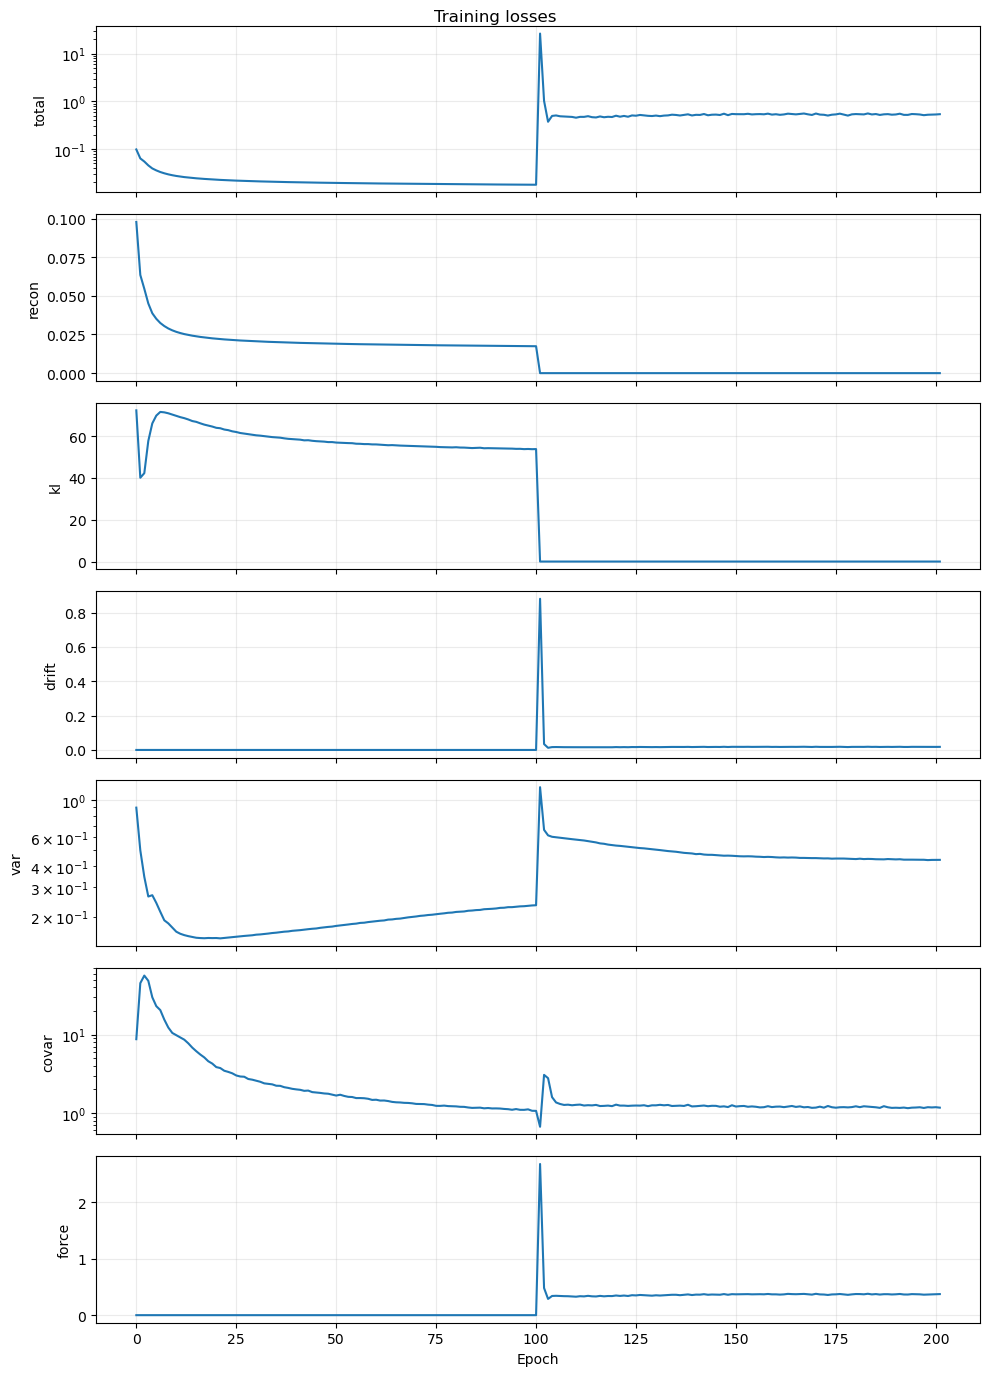

In [10]:
history = {
    "total": losses, "recon": recon_losses, "kl": kl_losses,
    "drift": drift_losses, "var": var_losses,
    "covar": covar_losses, "force": average_V,
}
fig, axes = plot_loss_history(history)
plt.show()


In [11]:
# Full-space metrics remain available under the same variables as separate.ipynb.
# Additional metrics are computed independently for every nested prefix.
post_eval = evaluate_matryoshka_model(
    f_trained,
    test_loader,
    device=device,
    dimensions=MATRYOSHKA_DIMS,
    n_samples=2048,
    n_classes=NUM_CLASSES,
    class_to_label=CLASS_TO_DIGIT,
    include_mmd=False,
    include_fid=True,
)

samples = post_eval["samples"]
real_latents = samples["real_latents"]
generated_latents = samples["generated_latents"]
real_pixels = samples["real_images"]
generated_pixels = samples["generated_images"]
real_class_labels = samples["real_class_ids"]
generated_class_labels = samples["generated_class_ids"]
real_labels = samples["real_labels"]
generated_labels = samples["generated_labels"]
metrics = post_eval["metrics"]
latent_stats = post_eval["statistics"]

print("Latent-space metrics:")
for name, value in metrics.items():
    print(f"{name}: {value:.6f}")


Latent-space metrics:
sliced_wasserstein: 0.241662
fid: 8.204008
class_coverage: 1.000000
class_entropy: 0.999253


In [12]:
# This is the same compact metric interface in pixel space.
# Its FID is a pixel-space Fréchet distance; use evaluate_mnist_generation with a
# frozen evaluator when you specifically want learned MNIST-feature FID.
pixel_metrics = evaluate_generation(
    real_pixels,
    generated_pixels,
    generated_labels=generated_class_labels,
    n_classes=NUM_CLASSES,
    include_mmd=False,
)
print("Pixel-space metrics:")
for name, value in pixel_metrics.items():
    print(f"{name}: {value:.6f}")


Pixel-space metrics:
sliced_wasserstein: 0.038828
fid: 7.164247
class_coverage: 1.000000
class_entropy: 0.999253


In [13]:
print("Latent statistics:")
for name, value in latent_stats.items():
    print(f"{name}: {value:.6f}")


Latent statistics:
real_latent_mean: 0.027601
generated_latent_mean: 0.053181
real_latent_std: 1.039626
generated_latent_std: 0.690680
generated_to_real_std_ratio: 0.664354
real_total_correlation: 3.298621
generated_total_correlation: 14.500163


In [14]:
matryoshka_metrics = post_eval["matryoshka_metrics"]
matryoshka_statistics = post_eval["matryoshka_statistics"]
prefix_reconstruction_mse = post_eval["matryoshka_reconstruction_mse"]
print("Matryoshka prefix metrics:")
for dimension in MATRYOSHKA_DIMS:
    print(f"dimension={dimension}")
    for name, value in matryoshka_metrics[dimension].items():
        print(f"{name}: {value:.6f}")
    print(f"reconstruction_mse: {prefix_reconstruction_mse[dimension]:.6f}")


Matryoshka prefix metrics:
dimension=4
sliced_wasserstein: 0.411481
fid: 0.907020
class_coverage: 1.000000
class_entropy: 0.999253
reconstruction_mse: 0.031524
dimension=8
sliced_wasserstein: 0.306807
fid: 1.285577
class_coverage: 1.000000
class_entropy: 0.999253
reconstruction_mse: 0.019290
dimension=16
sliced_wasserstein: 0.264070
fid: 3.935462
class_coverage: 1.000000
class_entropy: 0.999253
reconstruction_mse: 0.012336
dimension=32
sliced_wasserstein: 0.241662
fid: 8.204008
class_coverage: 1.000000
class_entropy: 0.999253
reconstruction_mse: 0.009690


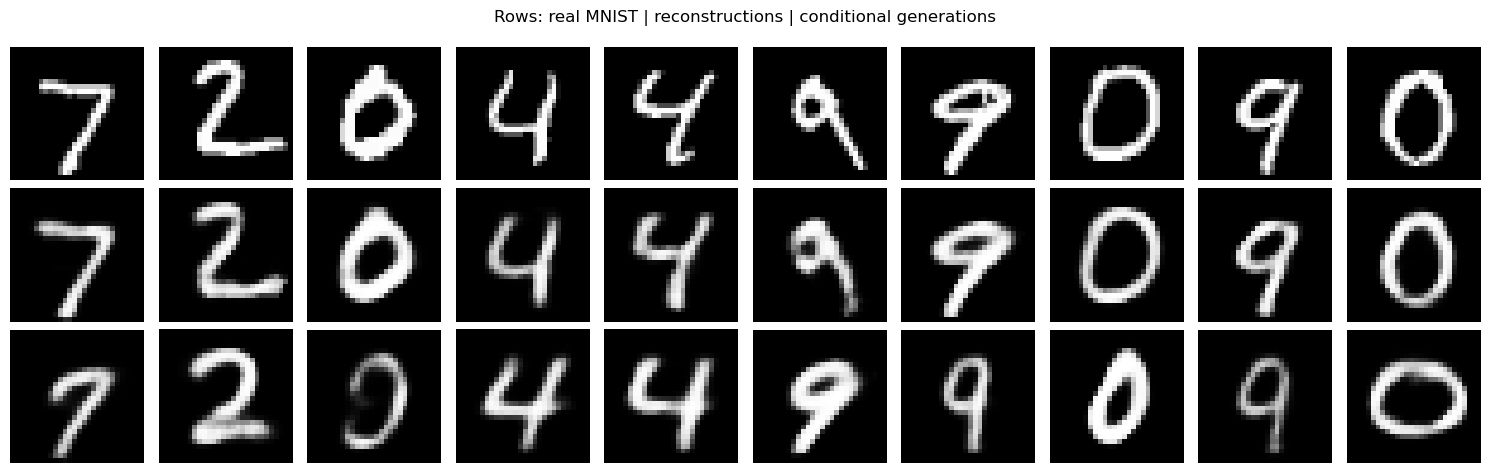

In [25]:
fig, axes = plot_conditional_mnist_results(
    f_trained,
    test_loader,
    device=device,
    samples=10,
    use_mean_for_reconstruction=True,
)
plt.show()


C:\Users\mateo\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\mateo\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


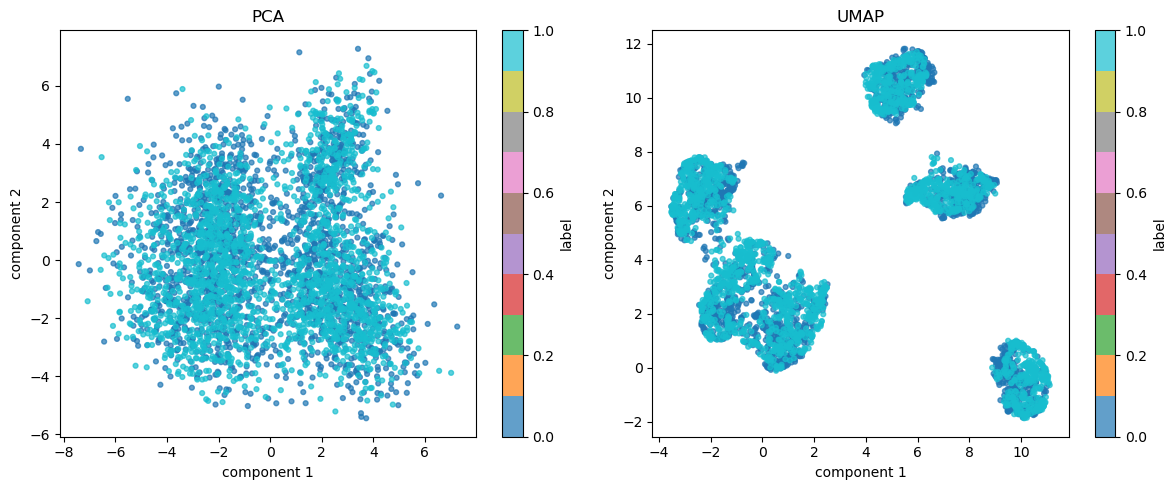

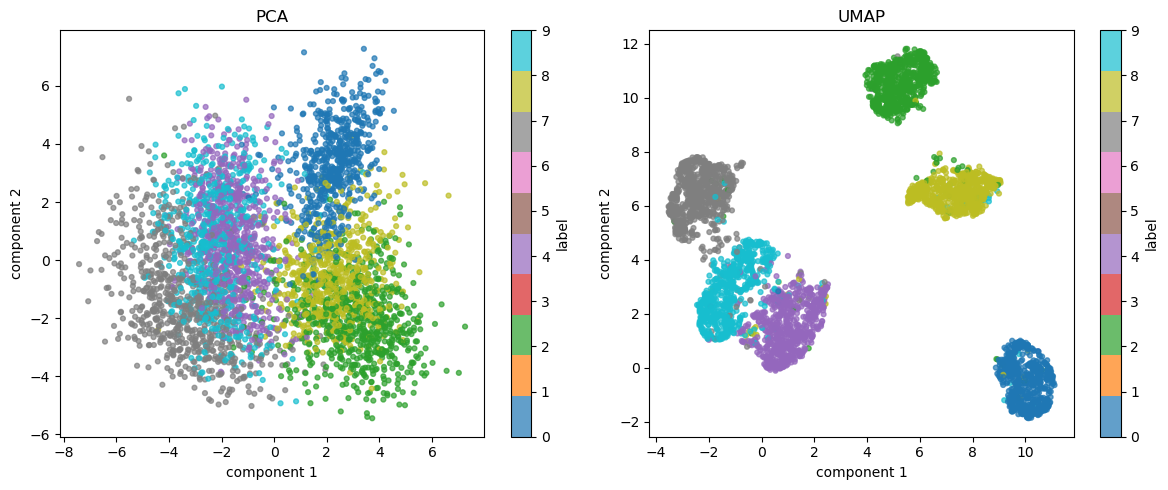

In [26]:
projection_figures = plot_real_generated_projections(
    real_latents,
    generated_latents,
    real_labels=real_labels,
    generated_labels=generated_labels,
    methods=("pca", "umap"),
)
plt.show()


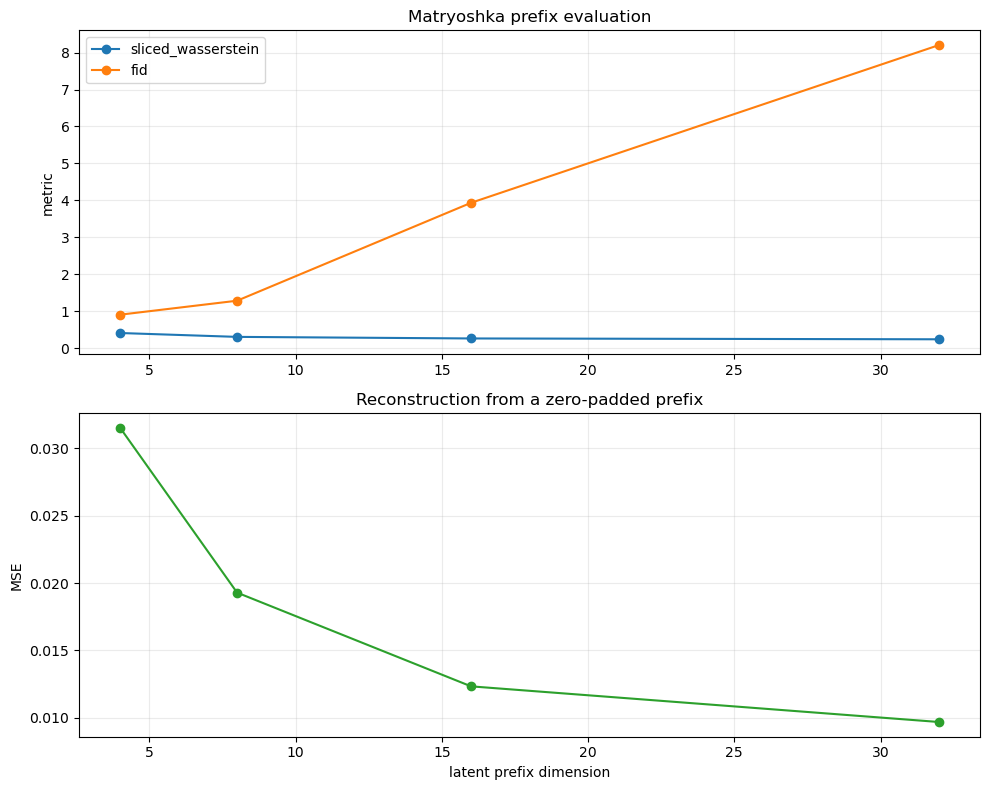

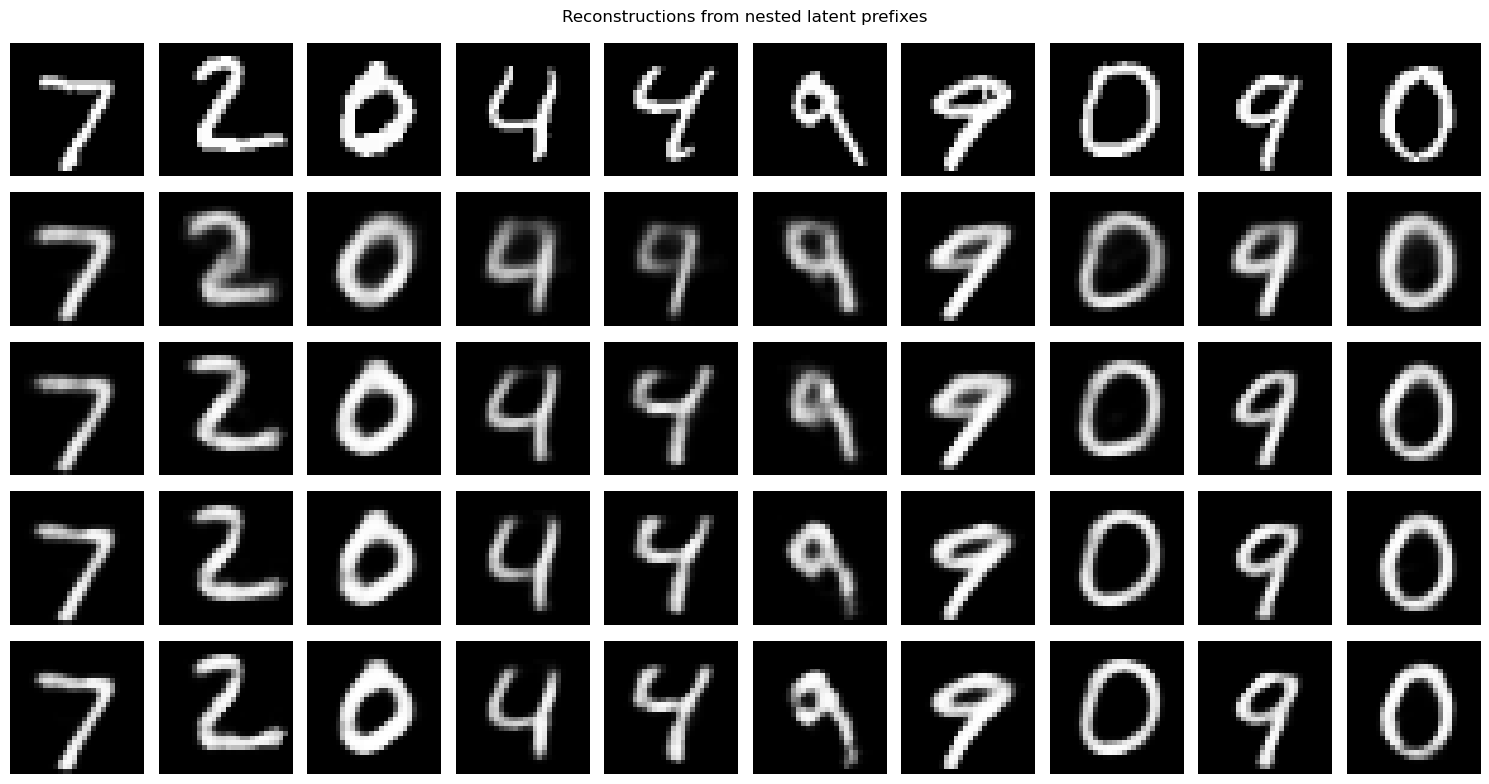

In [27]:
import importlib
import src.matryoshka as matryoshka_utils
matryoshka_utils = importlib.reload(matryoshka_utils)
plot_matryoshka_diagnostics = matryoshka_utils.plot_matryoshka_diagnostics
plot_matryoshka_reconstructions = matryoshka_utils.plot_matryoshka_reconstructions

fig, axes = plot_matryoshka_diagnostics(
    matryoshka_metrics,
    prefix_reconstruction_mse,
)
plt.show()

fig, axes = plot_matryoshka_reconstructions(
    f_trained,
    test_loader,
    MATRYOSHKA_DIMS,
    device=device,
    samples=10,
)
plt.show()
